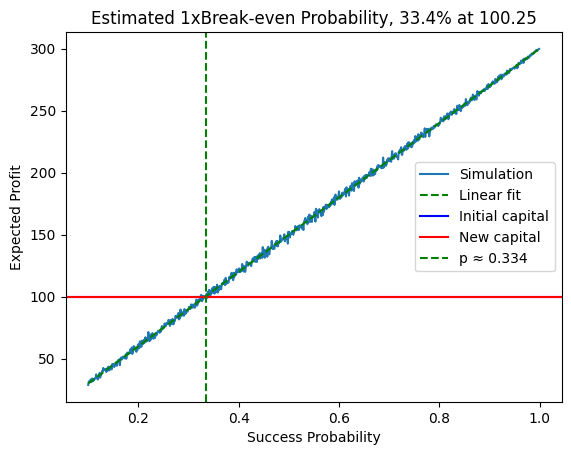

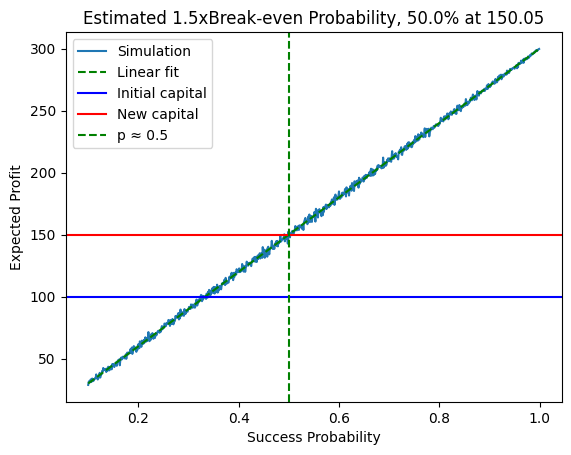

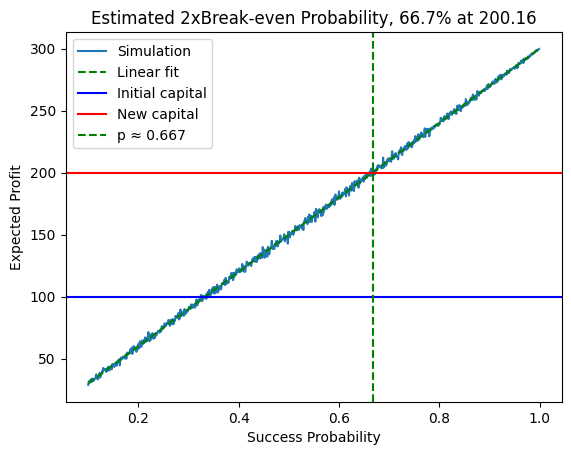

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

CAPITAL = 100

def experiment(p, iterations=100):
    capital = CAPITAL
    for _ in range(iterations):
        if random.random() <= p:
            capital += 2
        else:
            capital -= 1
    return capital

rands = np.arange(0.1, 1.0, 0.001)
mean_profit = []

for p in rands:
    profits = [experiment(p) for _ in range(50)]
    mean_profit.append(np.mean(profits))


# create an equation for the data and generate predictions that imitate the original data
slope, intercept = np.polyfit(rands, mean_profit, 1)
predictor = lambda x: slope * x + intercept
y_preds = predictor(rands)


# find where we break even
def ratio_for_desired_profit(scalar:float = 1):
    new_capital = CAPITAL * scalar
    break_idx = np.where(y_preds >= new_capital)[0][0]
    thresh = round(rands[break_idx], 3)

    # plot the data
    plt.plot(rands, mean_profit, label="Simulation")
    plt.plot(rands, y_preds, 'g--', label="Linear fit")
    plt.axhline(CAPITAL, color='blue', label="Initial capital")
    plt.axhline(new_capital, color='r', label="New capital")
    plt.axvline(thresh, color='g', linestyle='--',
                label=f"p ≈ {thresh}")

    plt.xlabel("Success Probability")
    plt.ylabel("Expected Profit")
    plt.title(f"Estimated {scalar}xBreak-even Probability, {thresh*100}% at {round(y_preds[break_idx], 2)}")
    plt.legend()
    plt.show()


ratio_for_desired_profit(scalar=1)
ratio_for_desired_profit(scalar=1.5)
ratio_for_desired_profit(scalar=2)
